### Applying K Means Clusteting algorithm to cluster satellites into 'shells'
- Since our dataset is completely ready for ML models, we will now group similar satellites together
using k means clustering unsupervised model

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [31]:
df = pd.read_csv('../data/04_scaled/satellites_scaled.csv')

In [32]:
df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_Q,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z
0,-2.005722,0.652233,1.309120,-1.121305,1.968277,-1.274152,-0.760235,0.162405,-0.053893,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-2.382847,0.387491,1.309733,-1.085740,0.868905,-0.174813,5.155879,0.015232,-0.057616,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-2.694500,2.110708,1.298236,0.215707,0.865634,0.809127,5.941114,0.015082,-0.057688,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-2.651757,2.229186,1.294617,-0.584462,-0.652645,1.015582,5.960924,0.043338,-0.057305,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.452026,-0.036020,0.345174,1.013130,1.761955,-1.726322,-0.818384,0.248900,-0.018401,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Import necessary libraries

In [33]:
from sklearn.cluster import KMeans

In [34]:
# Create a model (we will use a random value for K), with a random state as 101
model = KMeans(n_clusters=5, random_state=101)

In [35]:
# Train and test the model
cluster_labels = model.fit_predict(df)

In [36]:
# predicted cluster label for each satellite
cluster_labels

array([4, 4, 4, ..., 1, 2, 2], shape=(11990,), dtype=int32)

In [37]:
# Make a seperate column
df['CLUSTER'] = cluster_labels

In [38]:
# Let's find the occurence of each cluster
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3      34
4     602
1    1069
0    4417
2    5868
Name: count, dtype: int64

---
#### The question is, how do we even interprete this, as we dont even know what that 0, 1 or any other cluster actually is..

In [39]:
df.corr(numeric_only=True)['CLUSTER'].sort_values()

ARG_OF_PERICENTER   -0.739352
MEAN_MOTION_DOT     -0.095562
BSTAR               -0.056790
SAT_TYPE_X          -0.027415
SAT_TYPE_U          -0.027213
SAT_TYPE_W          -0.025688
SAT_TYPE_S          -0.025531
SAT_TYPE_P          -0.024408
SAT_TYPE_Q          -0.023913
SAT_TYPE_N          -0.023422
SAT_TYPE_R          -0.021627
SAT_TYPE_V          -0.021004
SAT_TYPE_Y          -0.020960
SAT_TYPE_M          -0.018482
SAT_TYPE_L          -0.014735
SAT_TYPE_H          -0.012295
MEAN_MOTION         -0.011003
ORBITAL_SPEED       -0.008919
SAT_TYPE_K          -0.008906
SAT_TYPE_J          -0.008739
MEAN_MOTION_DDOT    -0.007874
SAT_TYPE_G          -0.007391
SAT_TYPE_T          -0.007036
PERIGEE             -0.006408
SAT_TYPE_Z          -0.001563
ORBIT_PERIOD_SEC     0.004734
ORBIT_HEIGHT         0.005781
SEMI_MAJOR_AXIS      0.005781
SAT_TYPE_F           0.007236
SAT_TYPE_E           0.010986
SAT_TYPE_D           0.015713
APOGEE               0.017557
SAT_TYPE_C           0.020649
RA_OF_ASC_

- Let's plot the above thing

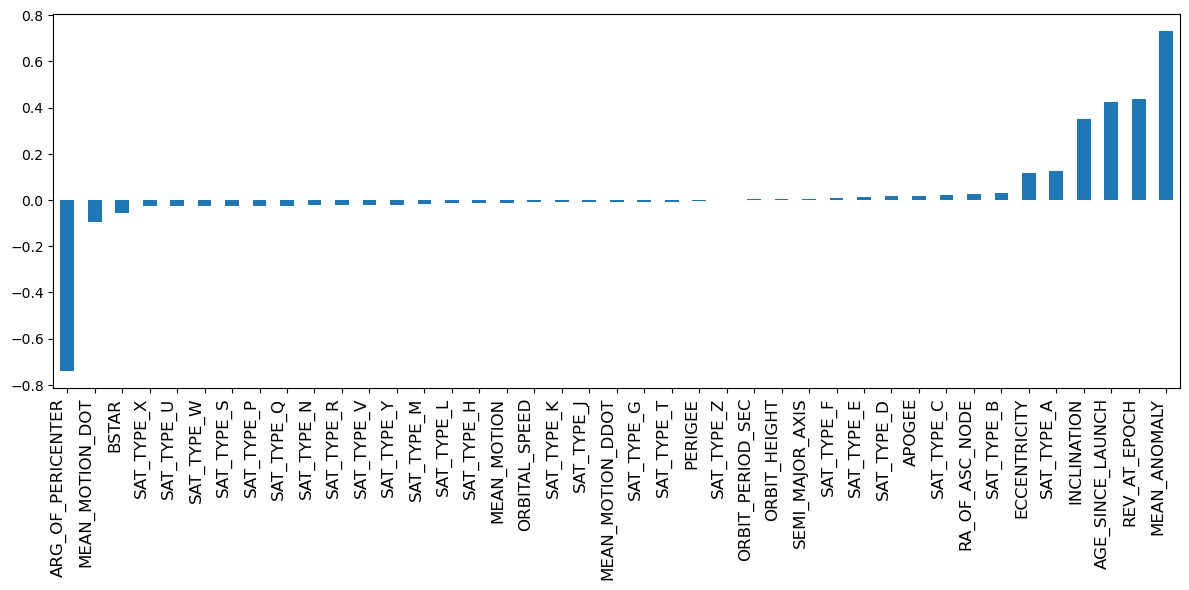

In [40]:
plt.figure(figsize=(12, 6))
df.corr(numeric_only=True)['CLUSTER'].sort_values()[:-1].plot(kind='bar')

plt.xticks(rotation=90, ha = 'right', fontsize = 12)
plt.tight_layout();

#### Interpreting the results for K = 5

- Let's consider the features having the most association with the cluster (both positive and negative)
- The featues most correlated are :
- ARG_OF_.., MEAN_MOTION_DOT, INCLINATION, AGE_SINCE_LAUNCH, REV_AT_EPOCH, MEAN_ANOMALY

In [41]:
most_corr_features = ['ARG_OF_PERICENTER', 'MEAN_MOTION_DOT', 'INCLINATION', 
                     'AGE_SINCE_LAUNCH', 'REV_AT_EPOCH', 'MEAN_ANOMALY'] 

In [42]:
grouped = df.groupby('CLUSTER')[most_corr_features].agg(['mean'])
grouped

,ARG_OF_PERICENTER,MEAN_MOTION_DOT,INCLINATION,AGE_SINCE_LAUNCH,REV_AT_EPOCH,MEAN_ANOMALY
,mean,mean,mean,mean,mean,mean
CLUSTER,,,,,,
0,1.149358,0.148446,-0.462692,-0.298134,-0.328875,-1.138811
1,-0.443167,-0.057922,0.973044,0.350991,0.331155,0.433233
2,-0.764246,-0.098656,0.030568,-0.136978,-0.103060,0.759722
3,-0.841592,-0.033602,0.327187,2.234044,2.426906,0.857553
4,-0.149100,-0.022775,1.350551,2.773218,2.692492,0.132554


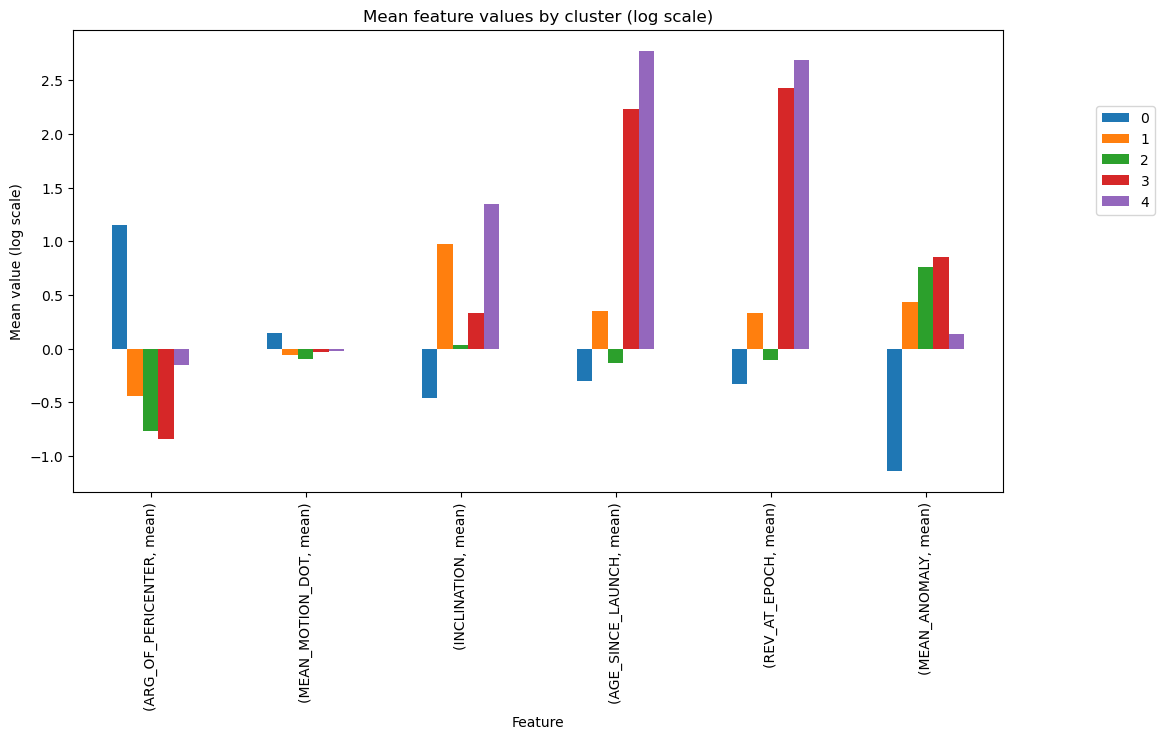

In [43]:
grouped.T.plot(kind='bar', figsize=(12,6)) 
plt.title("Mean feature values by cluster (log scale)")
plt.ylabel("Mean value (log scale)")
plt.xlabel("Feature")
plt.legend(loc=[1.1, 0.6])
plt.show()


- Physical meaning: 

| Cluster | Main Characteristic                             | Possible Satellite Type                     |
| ------- | ----------------------------------------------- | ------------------------------------------- |
| 0       | Newer, low-inclination, similar orientation     | Recently launched LEO constellations        |
| 1       | Mid-age, polar inclination                      | Earth-observation / reconnaissance          |
| 2       | Average across features                         | Transitional group                          |
| 3       | Old, low-moderate inclination, many revolutions | Aging operational satellites                |
| 4       | Very old, high-inclination                      | Polar / scientific or navigation satellites |


---
### Choosing optimal K value for clustering

In [44]:
ssd = []

# loop through k = 2 to 10 (basic estimation)
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=101)

    model.fit_predict(df) # Train the model
    ssd.append(model.inertia_) # append the SSD / inertia to the list

In [45]:
ssd # summed up ssd for each k value

[158279.60922520162,
 125798.2843187706,
 112228.58804203758,
 98140.71939001062,
 95934.41583601262,
 87847.5405212766,
 82117.76993169196,
 78483.76612516162,
 66627.82728093899]

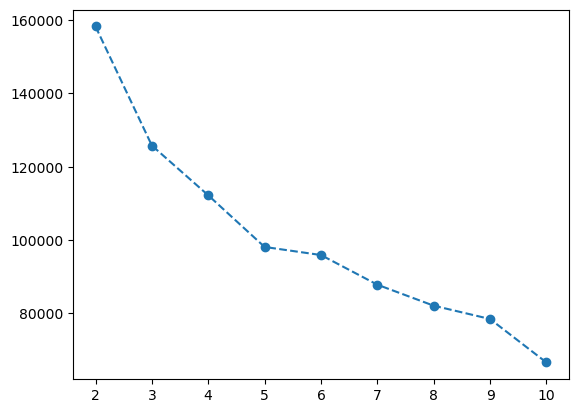

In [46]:
# Let's plot this
plt.plot(range(2, 11), ssd, 'o--')

- Let's find the difference between the SSDs

In [47]:
pd.Series(ssd).diff()

0             NaN
1   -32481.324906
2   -13569.696277
3   -14087.868652
4    -2206.303554
5    -8086.875315
6    -5729.770590
7    -3634.003807
8   -11855.938844
dtype: float64

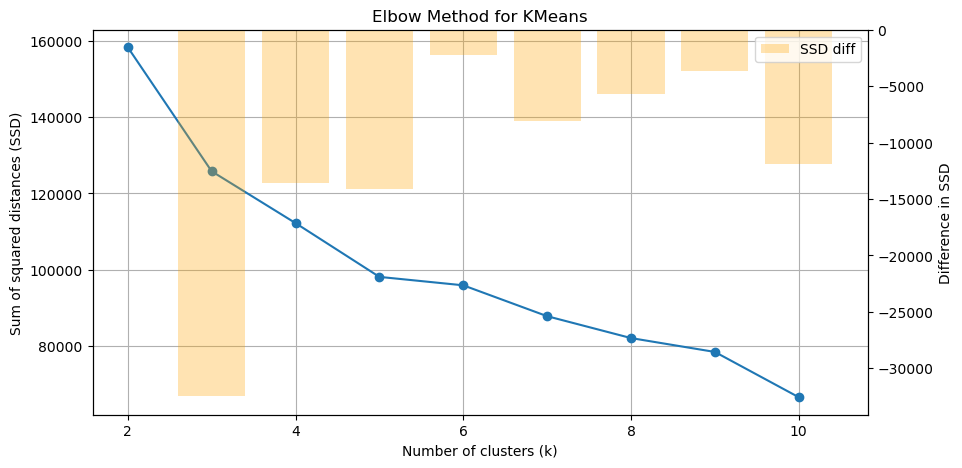

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Your SSD values for k=2 to 10
K_range = range(2, 11)
# replace with your real SSD values

# Convert to Series for diff calculation
ssd_series = pd.Series(ssd, index=K_range)
ssd_diff = ssd_series.diff()

# Plot SSD vs K
plt.figure(figsize=(10,5))
plt.plot(K_range, ssd, 'o-', label='SSD (Inertia)')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances (SSD)')
plt.grid(True)

# Optional: show the difference as a bar
plt.twinx()
plt.bar(K_range, ssd_diff, alpha=0.3, color='orange', label='SSD diff')
plt.ylabel('Difference in SSD')
plt.legend(loc='upper right')

plt.show()


---
### KMeans Clustering Interpretation

We applied KMeans clustering to our scaled satellite dataset and used the **Elbow Method** to determine the optimal number of clusters.  

**Elbow Analysis:**  
- The plot of **Sum of Squared Distances (SSD) vs. number of clusters (k)** shows that SSD decreases sharply at first, then the rate of decrease slows down.  
- The **difference in SSD** (`.diff()`) highlights how much each additional cluster improves clustering.  
- Observing the plot, the “elbow” appears around **k = 5**, where adding more clusters provides diminishing returns.  

**Cluster Summary (k = 5):**  
1. **Cluster 0:**  
   - Low inclination (orbits close to equator)  
   - ARG_OF_PERICENTER above average → closest approach happens later along orbit  
   - Relatively new satellites  

2. **Cluster 1:**  
   - Moderate-to-high inclination → satellites tilted more from equator  
   - Average orbital orientation and age  

3. **Cluster 2:**  
   - Features close to dataset average → “typical” satellites  
   - No extreme orbital characteristics  

4. **Cluster 3:**  
   - High age and number of revolutions → older satellites  
   - Moderate inclination and ARG_OF_PERICENTER  

5. **Cluster 4:**  
   - Oldest satellites with many revolutions  
   - High inclination → likely polar or near-polar orbits  
   - Moderate ARG_OF_PERICENTER  




-----
#### Validating more for optimal K value
- We will use n_init=50 and also validate using the  Silhouette Score

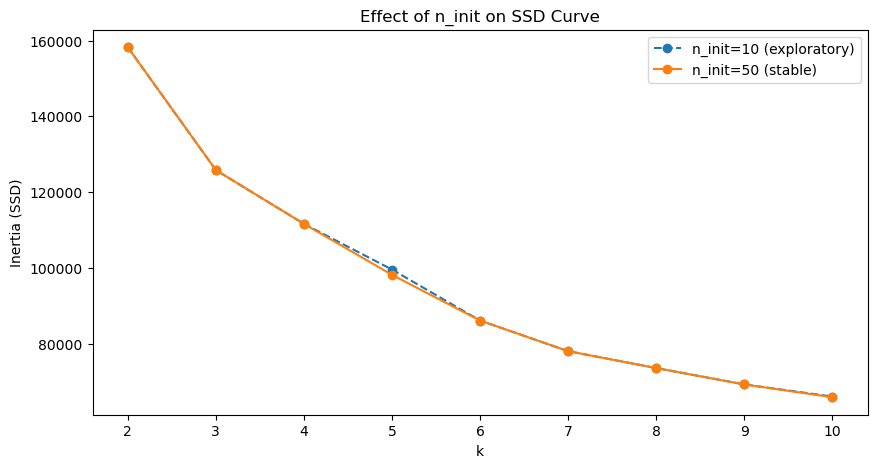

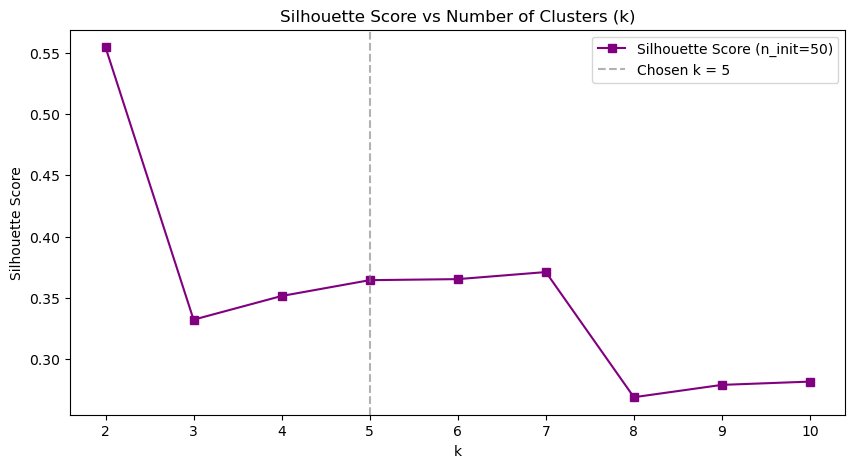

,k,SSD (n_init=50),Silhouette Score
0,2,158226.073168,0.554356
1,3,125798.224648,0.332274
2,4,111597.414587,0.351586
3,5,98140.719390,0.364485
4,6,86080.194692,0.365326
5,7,77993.308043,0.371088
6,8,73527.407243,0.269067
7,9,69207.234246,0.279132
8,10,65828.613225,0.281800


In [49]:
#!-------------- NOTE:  This code takes ages to run !! ------------------
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

ssd_10, ssd_50, sil_scores = [], [], []

for k in range(2, 11):
    km10 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(df)
    km50 = KMeans(n_clusters=k, n_init=50, random_state=42).fit(df)
    
    ssd_10.append(km10.inertia_)
    ssd_50.append(km50.inertia_)
    
    # silhouette score (using the more stable fit)
    labels = km50.labels_
    sil = silhouette_score(df, labels)
    sil_scores.append(sil)

# --- Plot 1: SSD (Inertia) ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), ssd_10, 'o--', label='n_init=10 (exploratory)')
plt.plot(range(2, 11), ssd_50, 'o-', label='n_init=50 (stable)')
plt.legend()
plt.title("Effect of n_init on SSD Curve")
plt.xlabel("k")
plt.ylabel("Inertia (SSD)")
plt.show()

# --- Plot 2: Silhouette Scores ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='purple', label='Silhouette Score (n_init=50)')
plt.axvline(5, color='gray', linestyle='--', alpha=0.6, label='Chosen k = 5')
plt.legend()
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

# --- Optional: print table ---
pd.DataFrame({
    'k': range(2, 11),
    'SSD (n_init=50)': ssd_50,
    'Silhouette Score': sil_scores
})


--- 
### 🛰️ Cluster Selection Analysis (KMeans)

We used two standard methods to determine the optimal number of clusters for our satellite dataset — the **Elbow Method** and the **Silhouette Score**.

#### 1. Elbow Method
The Elbow Method evaluates how the total **within-cluster variance (SSD)** decreases as the number of clusters (K) increases.  
In our case, the curve showed a clear “bend” or **elbow around K = 5**, indicating that after 5 clusters, the improvement in compactness slows down.  
This suggests that **five clusters offer a balanced tradeoff** between capturing meaningful structure and avoiding overfitting.

#### 2. Silhouette Score
The Silhouette Score measures **how well each data point fits within its cluster compared to others**, ranging from -1 to +1.  
A higher score means better separation between clusters.  
Our scores peaked at **K = 2 (≈0.55)**, suggesting that the dataset could be broadly separated into two main groups.  
However, since our dataset includes **only LEO-type satellites (no GEO or MEO)**, this “two-cluster” pattern likely reflects very broad distinctions (e.g., stable vs. decaying orbits), rather than detailed substructures.

#### 3. Why They Differ
- **Elbow** focuses on minimizing internal variance (compactness).
- **Silhouette** focuses on maximizing separation (distinctness).
- When both methods disagree, it usually means the data has **one dominant split** but also **smaller, meaningful variations** within that main structure.

#### 4. Final Choice — K = 5
We selected **K = 5** because:
- It aligns with the elbow point, balancing compactness and complexity.  
- It allows for finer segmentation of orbital behavior — capturing subtle subgroups such as:
  - satellites with stable vs. decaying orbits,  
  - newer vs. older launches,  
  - variations in inclination or mean motion behavior.  

Thus, **K = 5** provides a richer, more interpretable analysis of LEO satellite dynamics without oversimplifying the orbital diversity present in the dataset.


---
### Save the model output as CSV file
- Save both (scaled+label -> for future Regression model) and (unscaled+label -> for Isolation forest model)

In [50]:
# Save scaled version (for regression)
df.to_csv('../data/05_labeled/satellites_scaled_labeled.csv', index=False)

In [73]:
# Save the unscaled version (for anomaly detection)
import joblib

# Import the featured engineered dataset (containing unscaled data values)
unscaled = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

# Get the encoder which we used to encode the engineered dataset
encoder = joblib.load('../data/04_scaled/encoder_sat_type.joblib')

# Apply the same encoding
encoded = encoder.transform(unscaled[['SAT_TYPE']])

df_encoded = pd.concat([unscaled.drop('SAT_TYPE', axis=1), pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['SAT_TYPE']))], axis=1)

# Merge the corresponding cluster label
df_encoded['CLUSTER'] = df['CLUSTER']

# Save the CSV
df_encoded.to_csv('../data/05_labeled/satellites_unscaled_labeled.csv', index=False)

In [70]:
df_encoded

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,3638,0.001091,1.074000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,82182,0.000110,8.200000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,92607,0.000109,6.300000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,92870,0.000297,1.650000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
4,14.724473,0.000425,69.9186,300.3182,327.8826,32.2060,2866,0.001667,1.053100e-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11985,13.690044,0.000828,86.4926,131.1986,194.1426,165.9503,84,0.000057,6.600000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
11986,13.691724,0.000782,86.4982,131.2085,185.9250,174.1819,84,0.000057,6.600000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
11987,13.692081,0.000762,86.4964,130.7257,181.6880,178.4255,102,0.000057,6.600000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
11988,14.928145,0.000503,34.9899,350.2538,13.0573,347.0262,96,0.000452,4.738000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


- Quick sanity check, wether or not the labels are correct or not

In [71]:
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3      34
4     602
1    1069
0    4417
2    5868
Name: count, dtype: int64

In [72]:
df_encoded['CLUSTER'].value_counts().sort_values()

CLUSTER
3      34
4     602
1    1069
0    4417
2    5868
Name: count, dtype: int64